# Climate indices with xclim integration

In this notebook, we show how Meteora supports the computation of climate indices via the `climate_indices` module, which process the time-series data frames as obtained by Meteora's clients into the inputs of several [of the climate indices implemented in xclim](https://xclim.readthedocs.io/en/stable/indices.html).

In [ ]:
import datetime as dt

import contextily as cx
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns
from shapely import geometry

from meteora import clients, climate_indices, units

We will use MeteoSwiss stations around Zurich and focus on the June to August periods (JJA) of 2024:

In [ ]:
region_bbox = [8.34, 47.28, 8.67, 47.54]
region = gpd.GeoSeries(geometry.box(*region_bbox), crs="epsg:4326")
# select study period
year = 2024
# months to consider when querying the data
start_month = 6
end_month = 8
# variables
variables = ["temperature", "relative_humidity", "precipitation", "wind_speed"]
# viz
cmap = "coolwarm"
figwidth = plt.rcParams["figure.figsize"][0]
figheight = plt.rcParams["figure.figsize"][0]

We will start by plotting the MeteoSwiss stations in the study area:

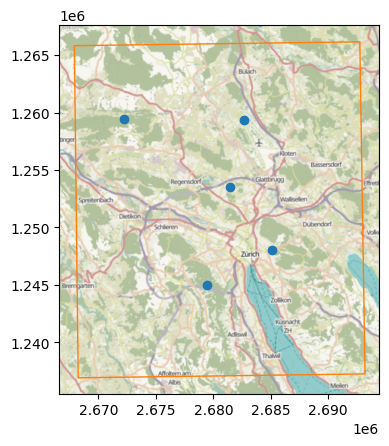

In [ ]:
client = clients.MeteoSwissClient(region)
colors = sns.color_palette()
ax = client.stations_gdf.plot(color=colors[0])
client.region.plot(ax=ax, facecolor=(0, 0, 0, 0), edgecolor=colors[1])
cx.add_basemap(ax=ax, crs=client.stations_gdf.crs, attribution=False)

*(C) OpenStreetMap contributors, Tiles style by Humanitarian OpenStreetMap Team hosted by OpenStreetMap France*

We can now get the JJA time series of measurements for the target year:

In [ ]:
ts_df = client.get_ts_df(
    variables,
    dt.date(year, start_month, 1),
    # get latest moment of the latest day of the month
    # ACHTUNG: this won't work if `end_month` is 12
    dt.datetime.combine(
        dt.date(year, end_month + 1, 1) - dt.timedelta(days=1), dt.time.max
    ),
)
ts_df.head()

temperature  relative_humidity  precipitation  \
station_id time                                                                 
KLO        2024-06-01 00:00:00         10.5               93.9            0.3   
           2024-06-01 00:10:00         10.5               96.8            0.3   
           2024-06-01 00:20:00         10.7               94.9            0.3   
           2024-06-01 00:30:00         10.5               97.0            0.2   
           2024-06-01 00:40:00         10.5               94.9            0.1   

                                wind_speed  
station_id time                             
KLO        2024-06-01 00:00:00         1.6  
           2024-06-01 00:10:00         1.9  
           2024-06-01 00:20:00         1.8  
           2024-06-01 00:30:00         1.8  
           2024-06-01 00:40:00         2.5

### Climate indices and input climate variables

We can compute several climate indices using temperature data only, which can be as simple as the number of  "hot days" with daily maximum temperature exceeds a given threshold:

In [ ]:
hot_days_df = climate_indices.hot_days(
    ts_df,
    thresh="30.0 degC",
    freq="YS",
)
hot_days_df.head()

station_id,KLO,LAE,REH,SMA,UEB
time,,,,,
2024-01-01,16,1,17,9,0


Let's visualize the number of hot days per station in the study area:

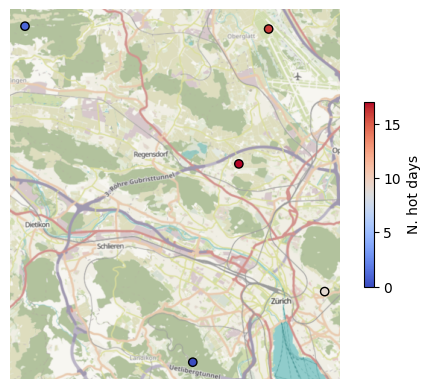

In [ ]:
hot_days_label = "N. hot days"
hot_days_gdf = gpd.GeoDataFrame(hot_days_df.T, geometry=client.stations_gdf["geometry"])
hot_days_gdf.columns = [hot_days_label, "geometry"]
ax = hot_days_gdf.plot(
    hot_days_label,
    cmap="coolwarm",
    edgecolor="k",
    legend=True,
    legend_kwds={"shrink": 0.5, "label": hot_days_label},
)
ax.set_axis_off()
cx.add_basemap(ax, crs=hot_days_gdf.crs, attribution=False)

*(C) OpenStreetMap contributors, Tiles style by Humanitarian OpenStreetMap Team hosted by OpenStreetMap France*

The computation of the hot days and other temperature-only indices will work as long as the input data frame contains a temperature column named "temperature" according to [the meteora nomenclature](https://meteora.readthedocs.io/en/latest/user-guide/overview.html#Selecting-variables). In the case where the temperature column has a different name, we need to provide that information explicitly through the `temperature_col` argument:

In [ ]:
climate_indices.hot_days(
    ts_df.rename(columns={"temperature": "tre200s0"}), temperature_col="tre200s0"
)

station_id,KLO,LAE,REH,SMA,UEB
time,,,,,
2024-01-01,52,20,49,42,0


Other climate indices require multiple climate variables as input. For instance, the heat index [1] requires temperature and relative humidity to estimate perceived temperature:

In [ ]:
climate_indices.heat_index(ts_df)

station_id,KLO,LAE,REH,SMA,UEB
time,,,,,
2024-06-01 00:00:00,NaN,NaN,NaN,NaN,NaN
2024-06-01 00:10:00,NaN,NaN,NaN,NaN,NaN
2024-06-01 00:20:00,NaN,NaN,NaN,NaN,NaN
2024-06-01 00:30:00,NaN,NaN,NaN,NaN,NaN
2024-06-01 00:40:00,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...
2024-08-31 23:10:00,NaN,23.241502,NaN,21.153045,NaN
2024-08-31 23:20:00,20.205266,22.983872,NaN,20.696908,NaN
2024-08-31 23:30:00,NaN,22.846435,NaN,20.719679,NaN


Here, the input data frame must contain both a temperature column named "temperature" and another column named "relative_humidity". If the columns have different names, we can provide them explicitly through the `temperature_col` and `relative_humidity_col` arguments.

### Climate indices and their default arguments

Most climate indices have additional arguments that can be used to customize their computation. For instance, note that while the heat index is computed at each time step, the hot days index aggregates the yearly counts. The yearly frequency is extracted from the signature of the underlying xclim method, in this case `xclim.indices.hot_days`, but we can choose another resampling frequency supported by xarray (e.g., [the "month start" `MS` frequency](https://pandas.pydata.org/pandas-docs/stable/user_guide/timeseries.html#offset-aliases)):

In [ ]:
climate_indices.hot_days(ts_df, freq="MS")

station_id,KLO,LAE,REH,SMA,UEB
time,,,,,
2024-06-01,10,2,9,8,0
2024-07-01,19,6,19,16,0
2024-08-01,23,12,21,18,0


Similarly, we can provide a different threshold value after which a day is considered "hot":

In [ ]:
climate_indices.hot_days(
    ts_df,
    thresh="25 degC",
    freq="YS",
)

station_id,KLO,LAE,REH,SMA,UEB
time,,,,,
2024-01-01,52,20,49,42,0


### Units and xclim compatibility

The xclim methods handle unit conversions when inputs include unit metadata, as it is the case with the time series returned by `get_ts_df` methods in Meteora - so indices work out of the box. For unit-naive data frames (e.g., custom data sources), you can pass explicit `*_unit` arguments, attach units with `meteora.units.attach_units`, or convert to canonical ECV units with `meteora.units.convert_units`.

For instance, consider the `METARASOSIEMClient`, which provides temperature in Fahrenheit, precipitation in inches and wind speed in knots:

In [ ]:
metar_client = clients.METARASOSIEMClient(region)
metar_client._variable_units_dict

{'tmpf': 'degF',
 'dwpf': 'degF',
 'relh': 'percent',
 'sknt': 'knot',
 'drct': 'degree',
 'mslp': 'hPa',
 'p01i': 'inch'}

We can get the time series for the same period as before:

In [ ]:
metar_ts_df = metar_client.get_ts_df(
    variables,
    dt.date(year, start_month, 1),
    # get latest moment of the latest day of the month
    # ACHTUNG: this won't work if `end_month` is 12
    dt.datetime.combine(
        dt.date(year, end_month + 1, 1) - dt.timedelta(days=1), dt.time.max
    ),
)
metar_ts_df

temperature  relative_humidity  precipitation  \
station_id time                                                                 
LSMD       2024-06-01 00:20:00         50.0              93.50            0.0   
           2024-06-01 00:50:00         50.0              93.50            0.0   
           2024-06-01 01:20:00         50.0              93.50            0.0   
           2024-06-01 01:50:00         48.2             100.00            0.0   
           2024-06-01 02:20:00         48.2             100.00            0.0   
...                                     ...                ...            ...   
LSZH       2024-08-30 21:50:00         68.0              82.86            0.0   
           2024-08-30 22:20:00         66.2              88.18            0.0   
           2024-08-30 22:50:00         66.2              88.18            0.0   
           2024-08-30 23:20:00         64.4              88.09            0.0   
           2024-08-30 23:50:00         64.4              88.09            0.0   

                                wind_speed  
station_id time                             
LSMD       2024-06-01 00:20:00         2.0  
           2024-06-01 00:50:00         2.0  
           2024-06-01 01:20:00         3.0  
           2024-06-01 01:50:00         3.0  
           2024-06-01 02:20:00         2.0  
...                                    ...  
LSZH       2024-08-30 21:50:00         2.0  
           2024-08-30 22:20:00         1.0  
           2024-08-30 22:50:00         0.0  
           2024-08-30 23:20:00         1.0  
           2024-08-30 23:50:00         2.0  

[8576 rows x 4 columns]

Because `metar_ts_df` includes units metadata, we can compute the hot days index directly and xclim will convert Fahrenheit internally:

In [ ]:
climate_indices.hot_days(
    metar_ts_df,
)

station_id,LSMD,LSZH
time,,
2024-01-01,57,56


If you drop the units metadata (or start from a unit-naive data frame), you need to provide the correct units explicitly, otherwise it would lead to misleading computed values:

In [ ]:
metar_ts_df_naive = metar_ts_df.copy()
metar_ts_df_naive.attrs = {}

climate_indices.hot_days(
    metar_ts_df_naive,
)

station_id,LSMD,LSZH
time,,
2024-01-01,91,91


For naive data frames, we can specify the units of each variable using the respective `*_unit` argument:

In [ ]:
climate_indices.hot_days(metar_ts_df_naive, temperature_unit="degF")

station_id,LSMD,LSZH
time,,
2024-01-01,57,56


Alternatively, we can attach units metadata to the unit-naive data frame using `units.attach_units` and compute the hot days index without providing the `temperature_unit` argument, since the data frame already carries the units metadata:

In [ ]:
metar_ts_df_units = units.attach_units(
    metar_ts_df_naive,
    metar_client._variable_units_dict,
)
climate_indices.hot_days(
    metar_ts_df_units,
)

station_id,LSMD,LSZH
time,,
2024-01-01,91,91


## Supported indices (MeteoSwiss example)

The climate indices from xclim currently implemented in `meteora.climate_indices` are:


In [ ]:
sorted(climate_indices.__all__)

['cooling_degree_days',
 'daily_temperature_range',
 'dry_days',
 'frost_days',
 'heat_index',
 'heating_degree_days',
 'hot_days',
 'hot_spell_frequency',
 'hot_spell_total_length',
 'humidex',
 'ice_days',
 'max_1day_precipitation_amount',
 'max_n_day_precipitation_amount',
 'prcptot',
 'sfc_wind_max',
 'sfc_wind_mean',
 'sfc_wind_min',
 'tn_days_above',
 'wetdays',
 'windy_days']

## See also
- The [xclim documentation on climate indices](https://xclim.readthedocs.io/en/stable/indices.html) for a detailed overview of ther arguments and default values.
- The [heatwave detection notebook](https://meteora.readthedocs.io/en/latest/user-guide/heatwave-detection.html) for heatwave detection and extraction of the underlying time series data of each heatwave.

## References
1. Blazejczyk, K., Epstein, Y., Jendritzky, G., Staiger, H., & Tinz, B. (2012). Comparison of UTCI to selected thermal indices. International journal of biometeorology, 56(3), 515-535.